In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import RobustScaler


## Baseline

In [ ]:
df = pd.read_pickle(r'D:\AV\Education\Master\ML\Project\prepared_data\data.pkl')

Первоначально построим baseline, просто выкинув все категориальные признаками

### Обработка данных

In [139]:
df3 = df.copy()

# Преобразуем типы данных
df3['host_response_time'] = df3['host_response_time'].apply(int)
for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    df3[col] = df3[col].apply(bool)

# Дропаем категориальные признаки
df3 = df3.select_dtypes(include=['int', 'bool', 'float'])

# Для признаков, содержащих мало пропусков, просто выкидываю незаполнные строки
few_null_values_col_list = [
    'host_listings_count',
    'host_total_listings_count',                         
    'minimum_minimum_nights',     
    'maximum_minimum_nights',       
    'minimum_maximum_nights',
    'maximum_maximum_nights',
]
for col in few_null_values_col_list:
    df3 = df3[~df3[col].isna()]

# Признаки, содержащие много пропусков пока просто удаляю
many_null_values_col_list = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'bedrooms',
    'latitude', # 
    'longitude',
]
df3 = df3.drop(columns=many_null_values_col_list)

# Убираю схожие по смыслу признаки
the_same_meaning_col_list = [
    'minimum_minimum_nights',  # Оставлю min_nights
    'maximum_minimum_nights',  # Оставлю min_nights 
    'minimum_nights_avg_ntm',  # Оставлю min_nights
    'minimum_maximum_nights',  # Оставлю max_nights 
    'maximum_maximum_nights',  # Оставлю max_nights 
    'maximum_nights_avg_ntm',  # Оставлю max_nights  
    'number_of_reviews_ltm',  # Оставлю number_of_reviews
    'number_of_reviews_l30d',  # Оставлю number_of_reviews
    'number_of_reviews_ly',  # Оставлю number_of_reviews
    'calculated_host_listings_count_entire_homes',  # Оставлю calculated_host_listings_count
    'calculated_host_listings_count_private_rooms',  # Оставлю calculated_host_listings_count
    'calculated_host_listings_count_shared_rooms',  # Оставлю calculated_host_listings_count
]
df3 = df3.drop(columns=the_same_meaning_col_list)


print(f'Кол-во пропусков = {df3.isnull().sum().sum()}')
print(f'Кол-во признаков = {df3.shape[1]}')
print(f'Кол-во строк = {df3.shape[0]}')

Кол-во пропусков = 0
Кол-во признаков = 19
Кол-во строк = 81820


### KNN v1
Обучим модель KNN на минимально-подготовленных данных

#### Без StandardScaler

In [140]:
# Делим данные на train и test
X = df3.drop(columns=['availability_30'])
y = df3['availability_30']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [144]:
# Создадим функцию для подбора и визуализации RMSE в зависимости от числа соседей
def draw_knn(df_list, nm_list, title_nm):

    plt.figure(figsize=(9, 5))

    color_list = ['blue', 'orange', 'green', 'black', 'red', 'grey']

    for i, df in enumerate(df_list):

        
        plt.plot(df['n'], df['rmse_test'], label=nm_list[i], color=color_list[i])

        min_idx = df['rmse_test'].idxmin()
        min_rmse = df.loc[min_idx, 'rmse_test']
        min_n = df.loc[min_idx, 'n']
        
        plt.scatter(min_n, min_rmse, color=color_list[i], zorder=5,
                    label=f"{nm_list[i]} min RMSE : {min_rmse:.4f} (n={min_n})")

    plt.legend()
    plt.title(title_nm)

100%|██████████| 38/38 [02:21<00:00,  3.74s/it]


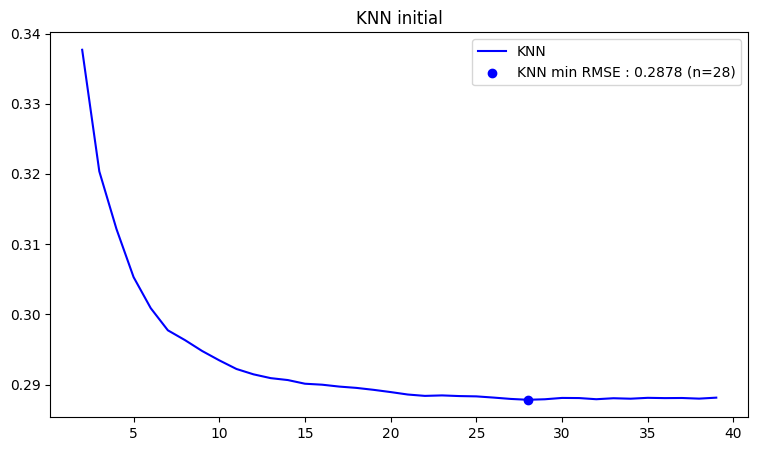

In [112]:


res = {
    'n': [],
    'rmse_test': [],
    'rmse_train': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train, y_train)

    y_test_pred = knn.predict(X_test)
    y_train_pred = knn.predict(X_train)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['rmse_train'] += [root_mean_squared_error(y_true=y_train,y_pred=y_train_pred)]

knn_initial_df = pd.DataFrame(res)

draw_knn([knn_initial_df], ['KNN'], title_nm='KNN initial')

#### Применение StandardScaler
Попробуем улучшить качество KNN за счет применение StandardScaler

  0%|          | 0/38 [00:00<?, ?it/s]

100%|██████████| 38/38 [02:03<00:00,  3.24s/it]


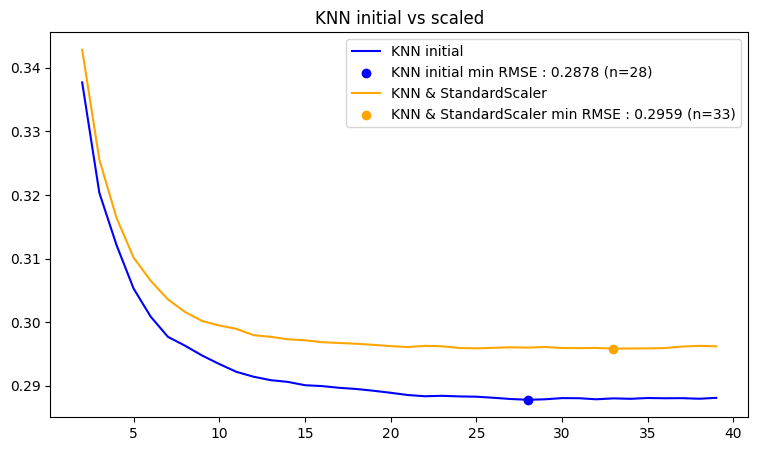

In [128]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

res = {
    'n': [],
    'rmse_test': [],
    'rmse_train': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled, y_train)

    y_test_pred = knn.predict(X_test_scaled)
    y_train_pred = knn.predict(X_train_scaled)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['rmse_train'] += [root_mean_squared_error(y_true=y_train,y_pred=y_train_pred)]

knn_scaled_df = pd.DataFrame(res)

draw_knn([knn_initial_df, knn_scaled_df], ['KNN initial', 'KNN & StandardScaler'], title_nm='KNN initial vs scaled')


Применение StandardScaler увеличило RMSE. Это может объясняться следующими факторами:
* Наличие существенных выбросов в данных (из-за этого среднее может сильно искажаться)
* Большое кол-во 0 в фичах

Проверим данные на наличие этих факторов


In [ ]:
# Функция размечающая выбросы по методу IQR +- 1.5 IQR
def find_outlier(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    iqr = q3 - q1

    return (x > q3 + iqr * 1.5) | (x < q1 - iqr * 1.5)

In [ ]:
# Посмотрим на долю выбросов и наибольшее отклонение выброса в каждом столбце
for col in df3.select_dtypes(include=['int', 'float']).columns:

    # Считаем долю выбросов в признаке
    outlier_perc = find_outlier(df3[col]).mean()

    iqr = df3[col].quantile(0.75) - df3[col].quantile(0.25)

    # Считаем на сколько IQR отклонилось максимальное значение от Q3
    n_iqr = (df3[col].max() - df3[col].quantile(0.75)) / iqr

    print(f'{col}: outlier_perc = {outlier_perc:.2%} max_iqr_deviation = {n_iqr:.2f}')

host_response_time: outlier_perc = 0.00% max_iqr_deviation = 0.00
host_response_rate: outlier_perc = 0.00% max_iqr_deviation = 0.00
host_acceptance_rate: outlier_perc = 0.00% max_iqr_deviation = 0.01
host_listings_count: outlier_perc = 19.64% max_iqr_deviation = 2765.67
host_total_listings_count: outlier_perc = 18.50% max_iqr_deviation = 1752.60
accommodates: outlier_perc = 2.60% max_iqr_deviation = 6.00
minimum_nights: outlier_perc = 21.62% max_iqr_deviation = 248.50
maximum_nights: outlier_perc = 0.00% max_iqr_deviation = 9215.55
availability_30: outlier_perc = 12.90% max_iqr_deviation = 2.33
number_of_reviews: outlier_perc = 10.14% max_iqr_deviation = 148.59
calculated_host_listings_count: outlier_perc = 19.22% max_iqr_deviation = 406.50
host_age_on_platform: outlier_perc = 0.00% max_iqr_deviation = 1.04


Действительно, большое кол-во признаков содержит большое кол-во выбросов. Попробуем использование другие скейлеров

100%|██████████| 38/38 [02:38<00:00,  4.17s/it]


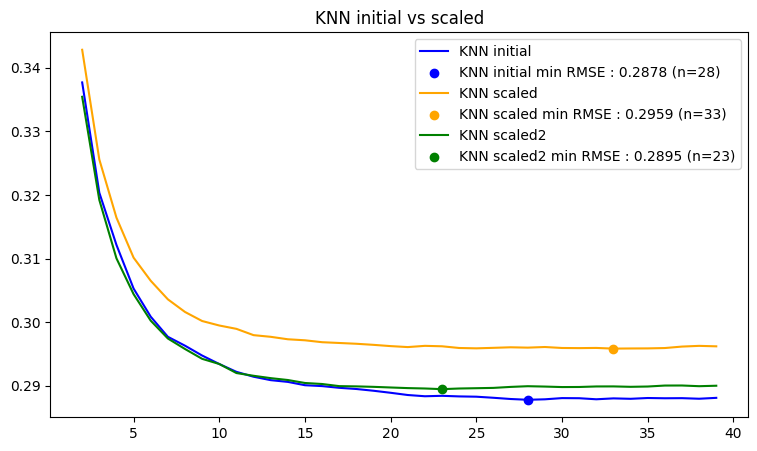

In [ ]:
scaler = RobustScaler()
X_train_scaled2 = scaler.fit_transform(X_train) 
X_test_scaled2 = scaler.transform(X_test)

res = {
    'n': [],
    'rmse_test': [],
    'rmse_train': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled2, y_train)

    y_test_pred = knn.predict(X_test_scaled2)
    y_train_pred = knn.predict(X_train_scaled2)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['rmse_train'] += [root_mean_squared_error(y_true=y_train,y_pred=y_train_pred)]

knn_scaled2_df = pd.DataFrame(res)

draw_knn(
    [knn_initial_df, knn_scaled_df, knn_scaled2_df], 
    ['KNN initial', 'KNN & StandardScaler', 'KNN & RobustScaler'], 
    title_nm='KNN initial vs scaled'
)


100%|██████████| 38/38 [02:22<00:00,  3.75s/it]


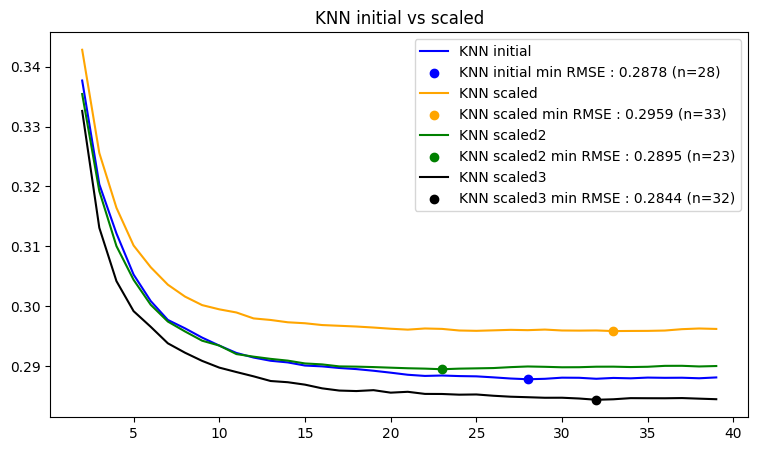

In [ ]:
scaler = FunctionTransformer(np.log1p, validate=True)

X_train_scaled2 = scaler.fit_transform(X_train) 
X_test_scaled2 = scaler.transform(X_test)

res = {
    'n': [],
    'rmse_test': [],
    'rmse_train': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled2, y_train)

    y_test_pred = knn.predict(X_test_scaled2)
    y_train_pred = knn.predict(X_train_scaled2)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['rmse_train'] += [root_mean_squared_error(y_true=y_train,y_pred=y_train_pred)]

knn_scaled3_df = pd.DataFrame(res)

draw_knn(
    [knn_initial_df, knn_scaled_df, knn_scaled2_df, knn_scaled3_df], 
    ['KNN initial', 'KNN & StandardScaler', 'KNN & RobustScaler', 'KNN & LogScaler'], 
    title_nm='KNN initial vs scaled'
)


In [129]:
from sklearn.preprocessing import MinMaxScaler

100%|██████████| 38/38 [01:54<00:00,  3.00s/it]


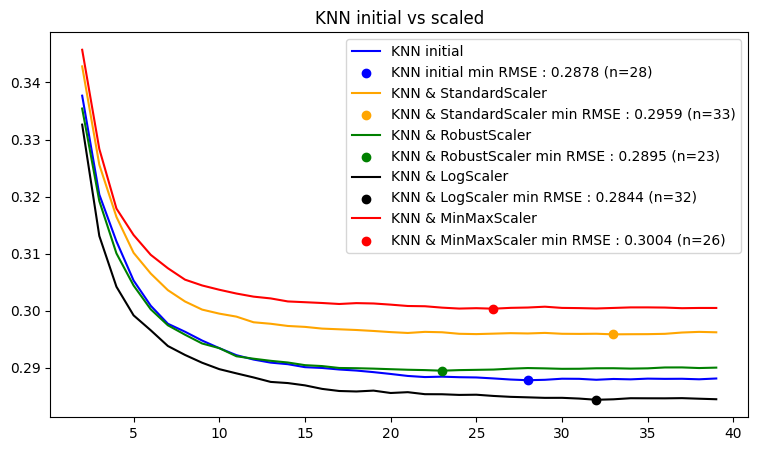

In [130]:
scaler = MinMaxScaler()

X_train_scaled2 = scaler.fit_transform(X_train) 
X_test_scaled2 = scaler.transform(X_test)

res = {
    'n': [],
    'rmse_test': [],
    'rmse_train': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled2, y_train)

    y_test_pred = knn.predict(X_test_scaled2)
    y_train_pred = knn.predict(X_train_scaled2)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test,y_pred=y_test_pred)]
    res['rmse_train'] += [root_mean_squared_error(y_true=y_train,y_pred=y_train_pred)]

knn_scaled4_df = pd.DataFrame(res)

draw_knn(
    [knn_initial_df, knn_scaled_df, knn_scaled2_df, knn_scaled3_df, knn_scaled4_df], 
    ['KNN initial', 'KNN & StandardScaler', 'KNN & RobustScaler', 'KNN & LogScaler', 'KNN & MinMaxScaler'], 
    title_nm='KNN initial vs scaled'
)


In [ ]:
def find_outlier(x):
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)

    iqr = q3 - q1

    return (x > q3 + iqr * 1.5) | (x < q1 - iqr * 1.5)

In [141]:
df4 = df3.copy()

for col in df4.select_dtypes(include=['int', 'float']).columns:

    if col != 'availability_30':  # не трогаем таргет
    
        # Считаем долю выбросов в признаке
        outlier_perc = find_outlier(df4[col]).mean()

        q1 = df4[col].quantile(0.25)
        q3 = df4[col].quantile(0.75)
        iqr = q3 - q1

        df4[col] = df4[col].apply(lambda x: q3 + 1.5 * iqr if x > q3 + 1.5 * iqr else x)
        df4[col] = df4[col].apply(lambda x: q1 - 1.5 * iqr if x < q1 - 1.5 * iqr else x)



In [142]:
for col in df4.select_dtypes(include=['int', 'float']).columns:

    # Считаем долю выбросов в признаке
    outlier_perc = find_outlier(df4[col]).mean()

    iqr = df4[col].quantile(0.75) - df4[col].quantile(0.25)

    # Считаем на сколько IQR отклонилось максимальное значение от Q3
    n_iqr = (df4[col].max() - df4[col].quantile(0.75)) / iqr

    print(f'{col}: outlier_perc = {outlier_perc:.2%} max_iqr_deviation = {n_iqr:.2f}')

host_response_time: outlier_perc = 0.00% max_iqr_deviation = 0.00
host_response_rate: outlier_perc = 0.00% max_iqr_deviation = 0.00
host_acceptance_rate: outlier_perc = 0.00% max_iqr_deviation = 0.01
host_listings_count: outlier_perc = 0.00% max_iqr_deviation = 1.50
host_total_listings_count: outlier_perc = 0.00% max_iqr_deviation = 1.50
accommodates: outlier_perc = 0.00% max_iqr_deviation = 1.50
minimum_nights: outlier_perc = 0.00% max_iqr_deviation = 1.50
maximum_nights: outlier_perc = 0.00% max_iqr_deviation = 1.50
availability_30: outlier_perc = 12.90% max_iqr_deviation = 2.33
number_of_reviews: outlier_perc = 0.00% max_iqr_deviation = 1.50
calculated_host_listings_count: outlier_perc = 0.00% max_iqr_deviation = 1.50
host_age_on_platform: outlier_perc = 0.00% max_iqr_deviation = 1.04


100%|██████████| 38/38 [02:43<00:00,  4.30s/it]


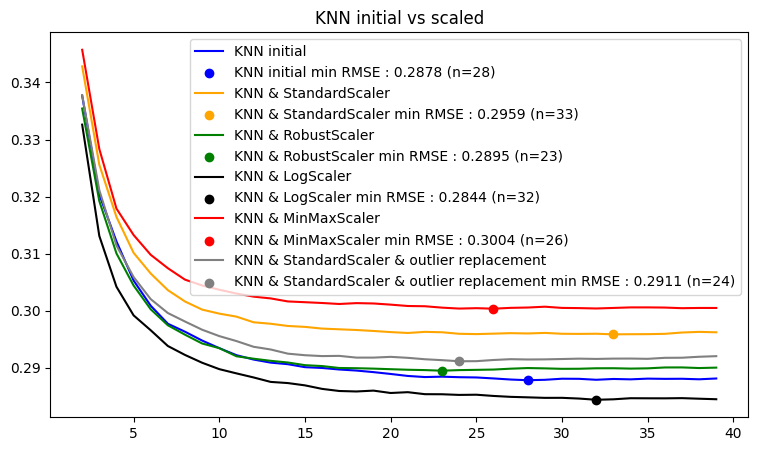

In [146]:
scaler = StandardScaler()
X2 = df4.drop(columns='availability_30')
y2 = df4['availability_30']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y)
X_train_scaled2 = scaler.fit_transform(X_train2) 
X_test_scaled2 = scaler.transform(X_test2)

res = {
    'n': [],
    'rmse_test': [],
    'rmse_train': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(n_neighbors=n)

    knn.fit(X_train_scaled2, y_train2)

    y_test_pred = knn.predict(X_test_scaled2)
    y_train_pred = knn.predict(X_train_scaled2)

    res['n'] += [n]
    res['rmse_test'] += [root_mean_squared_error(y_true=y_test2,y_pred=y_test_pred)]
    res['rmse_train'] += [root_mean_squared_error(y_true=y_train2,y_pred=y_train_pred)]

knn_scaled6_df = pd.DataFrame(res)

draw_knn(
    [knn_initial_df, knn_scaled_df, knn_scaled2_df, knn_scaled3_df, knn_scaled4_df, knn_scaled6_df], 
    ['KNN initial', 'KNN & StandardScaler', 'KNN & RobustScaler', 'KNN & LogScaler', 'KNN & MinMaxScaler', 'KNN & StandardScaler & outlier replacement'], 
    title_nm='KNN initial vs scaled'
)


## Model implementation

In [ ]:
def get_regression_quality_metrics(y_test, y_test_pred, y_train=None, y_train_pred=None, print_metrics=True):
    rmse_test = root_mean_squared_error(
        y_true=y_test,
        y_pred=y_test_pred,
    )

    if y_train is not None and y_train_pred is not None:
        rmse_train = root_mean_squared_error(
            y_true=y_train,
            y_pred=y_train_pred,
        )

    if print_metrics:
        print(f'RMSE (test): {rmse_test:.4f}')
        print(f'RMSE (train): {rmse_train:.4f}')

    if y_train is None and y_train_pred is None:
        return rmse_test 
    else:
        return rmse_test, rmse_train

#### KNN

##### StandardScaler

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

In [14]:
X_train

,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,accommodates,minimum_nights,...,number_of_reviews_ly,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,host_verifications_email,host_verifications_phone,host_verifications_work_email,host_age_on_platform
10654,72,0.00,0.00,False,1.0,1.0,True,False,4,365,...,0,False,1,1,0,0,False,True,False,9.249315
37175,24,1.00,0.73,True,1.0,3.0,True,True,2,3,...,17,False,1,1,0,0,True,True,False,10.358904
4739,72,0.00,0.00,False,1.0,1.0,True,True,5,365,...,0,True,1,1,0,0,True,True,True,11.345205
52484,72,0.00,0.00,False,1.0,1.0,True,True,2,1,...,0,False,1,1,0,0,True,True,False,1.794521
41614,72,0.00,0.00,False,1.0,1.0,True,True,2,4,...,0,False,1,1,0,0,True,True,False,8.523288
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52528,1,0.99,0.98,False,167.0,172.0,True,True,4,30,...,1,True,68,68,0,0,True,True,False,11.520548
18681,1,1.00,1.00,False,85.0,94.0,True,True,4,2,...,11,True,65,65,0,0,True,True,False,8.994521
6596,72,0.00,0.00,False,1.0,1.0,True,True,2,365,...,0,False,1,1,0,0,True,True,False,11.112329
70826,1,0.99,1.00,False,37.0,39.0,True,True,4,1,...,2,True,17,17,0,0,True,True,False,3.898630


In [15]:
scaler.fit_transform(X_train[['host_is_superhost', 'host_has_profile_pic']])

array([[-0.51033493,  0.18662365],
       [ 1.95949746,  0.18662365],
       [-0.51033493,  0.18662365],
       ...,
       [-0.51033493,  0.18662365],
       [-0.51033493,  0.18662365],
       [-0.51033493,  0.18662365]], shape=(65456, 2))

In [16]:


res = {
    'n': [],
    'rmse': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(
        n_neighbors=n
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    res['n'] += [n]
    res['rmse'] += [root_mean_squared_error(
        y_true=y_test,
        y_pred=y_pred,
    )]

df_t2 = pd.DataFrame(res)

100%|██████████| 38/38 [00:27<00:00,  1.39it/s]


##### StandardScaler + PCA

In [17]:
# Импортируем метод PCA из модуля decomposition библиотеки sklearn
from sklearn.decomposition import PCA

# Создадим объект класса PCA с числом главных компонент равным 7
pca = PCA(n_components = 10)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) 
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pca.fit_transform(X_train_scaled)
X_test_scaled = pca.transform(X_test_scaled)

res = {
    'n': [],
    'rmse': [],
}

for n in tqdm(range(2, 40)):
    knn = KNeighborsRegressor(
        n_neighbors=n
    )

    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)

    res['n'] += [n]
    res['rmse'] += [root_mean_squared_error(
        y_true=y_test,
        y_pred=y_pred,
    )]

df_t3 = pd.DataFrame(res)

100%|██████████| 38/38 [01:26<00:00,  2.27s/it]


Text(0.5, 1.0, 'KNN')

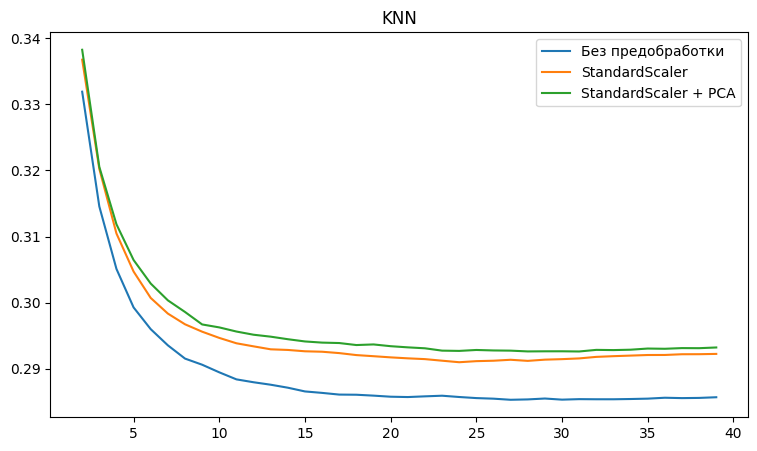

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(df_t['n'], df_t['rmse'], label='Без предобработки')

plt.plot(df_t2['n'], df_t2['rmse'], label='StandardScaler')

plt.plot(df_t3['n'], df_t3['rmse'], label='StandardScaler + PCA')


plt.legend()
plt.title('KNN')

### LinearRegression

In [19]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

lin_reg.fit(X_train, y_train)

y_test_pred = lin_reg.predict(X_test)
y_train_pred = lin_reg.predict(X_train)

get_regression_quality_metrics(
    y_test= y_test,
    y_test_pred=y_test_pred,
    y_train=y_train, 
    y_train_pred=y_train_pred,
)


RMSE (test): 0.3170
RMSE (train): 0.3166


(0.3170405017863853, 0.31661172313979646)

### DecisionTreeRegressor

In [20]:
from sklearn.tree import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor()

tree_reg.fit(X_train, y_train)

y_test_pred = tree_reg.predict(X_test)
y_train_pred = tree_reg.predict(X_train)

get_regression_quality_metrics(
    y_test= y_test,
    y_test_pred=y_test_pred,
    y_train=y_train, 
    y_train_pred=y_train_pred,
)


RMSE (test): 0.3834
RMSE (train): 0.0302


(0.3834037577922176, 0.030245168680836564)

Видим явное сильное переобучение модели

100%|██████████| 19/19 [00:08<00:00,  2.16it/s]


<Axes: xlabel='min_samples_leaf'>

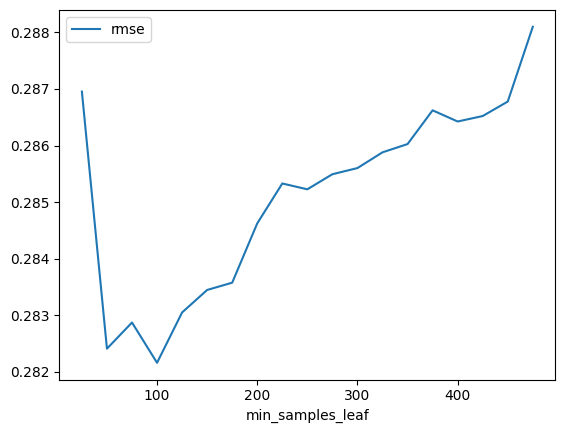

In [21]:
res = {
    'min_samples_leaf': [],
    'rmse': [],
}

for min_samples_leaf in tqdm(range(25, 500, 25)):

    tree_reg = DecisionTreeRegressor(min_samples_leaf=min_samples_leaf)

    tree_reg.fit(X_train, y_train)

    y_test_pred = tree_reg.predict(X_test)
    y_train_pred = tree_reg.predict(X_train)

    res['min_samples_leaf'] += [min_samples_leaf]
    res['rmse'] += [root_mean_squared_error(
        y_true=y_test,
        y_pred=y_test_pred,
    )]

df_t3 = pd.DataFrame(res)

df_t3.plot(kind='line', x='min_samples_leaf', y='rmse')

100%|██████████| 20/20 [00:09<00:00,  2.17it/s]


<Axes: xlabel='min_samples_leaf'>

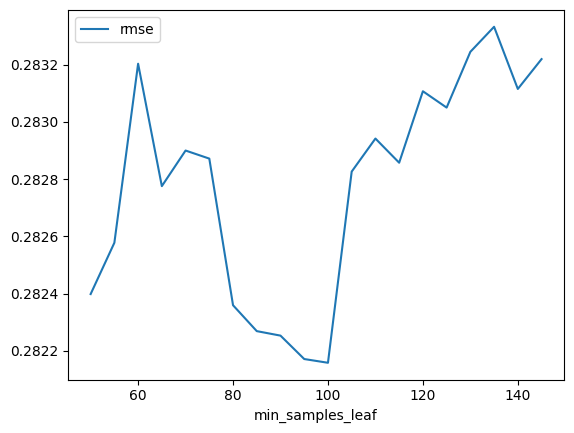

In [22]:
res = {
    'min_samples_leaf': [],
    'rmse': [],
}

for min_samples_leaf in tqdm(range(50, 150, 5)):

    tree_reg = DecisionTreeRegressor(min_samples_leaf=min_samples_leaf)

    tree_reg.fit(X_train, y_train)

    y_test_pred = tree_reg.predict(X_test)
    y_train_pred = tree_reg.predict(X_train)

    res['min_samples_leaf'] += [min_samples_leaf]
    res['rmse'] += [root_mean_squared_error(
        y_true=y_test,
        y_pred=y_test_pred,
    )]

df_t3 = pd.DataFrame(res)

df_t3.plot(kind='line', x='min_samples_leaf', y='rmse')

100%|██████████| 19/19 [00:15<00:00,  1.24it/s]


<Axes: xlabel='min_samples_leaf'>

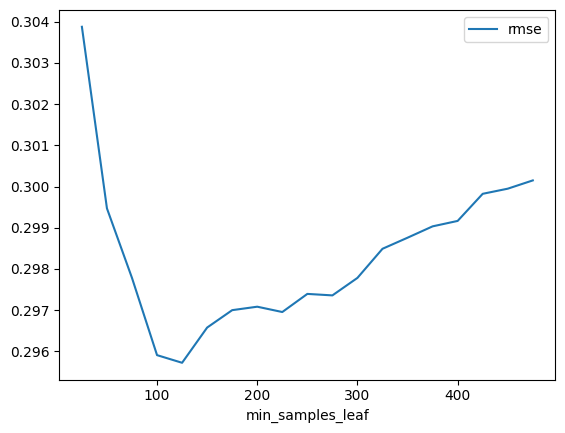

In [23]:
res = {
    'min_samples_leaf': [],
    'rmse': [],
}

for min_samples_leaf in tqdm(range(25, 500, 25)):

    tree_reg = DecisionTreeRegressor(min_samples_leaf=min_samples_leaf)

    tree_reg.fit(X_train_scaled, y_train)

    y_test_pred = tree_reg.predict(X_test_scaled)
    y_train_pred = tree_reg.predict(X_train_scaled)

    res['min_samples_leaf'] += [min_samples_leaf]
    res['rmse'] += [root_mean_squared_error(
        y_true=y_test,
        y_pred=y_test_pred,
    )]

df_t3 = pd.DataFrame(res)

df_t3.plot(kind='line', x='min_samples_leaf', y='rmse')

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

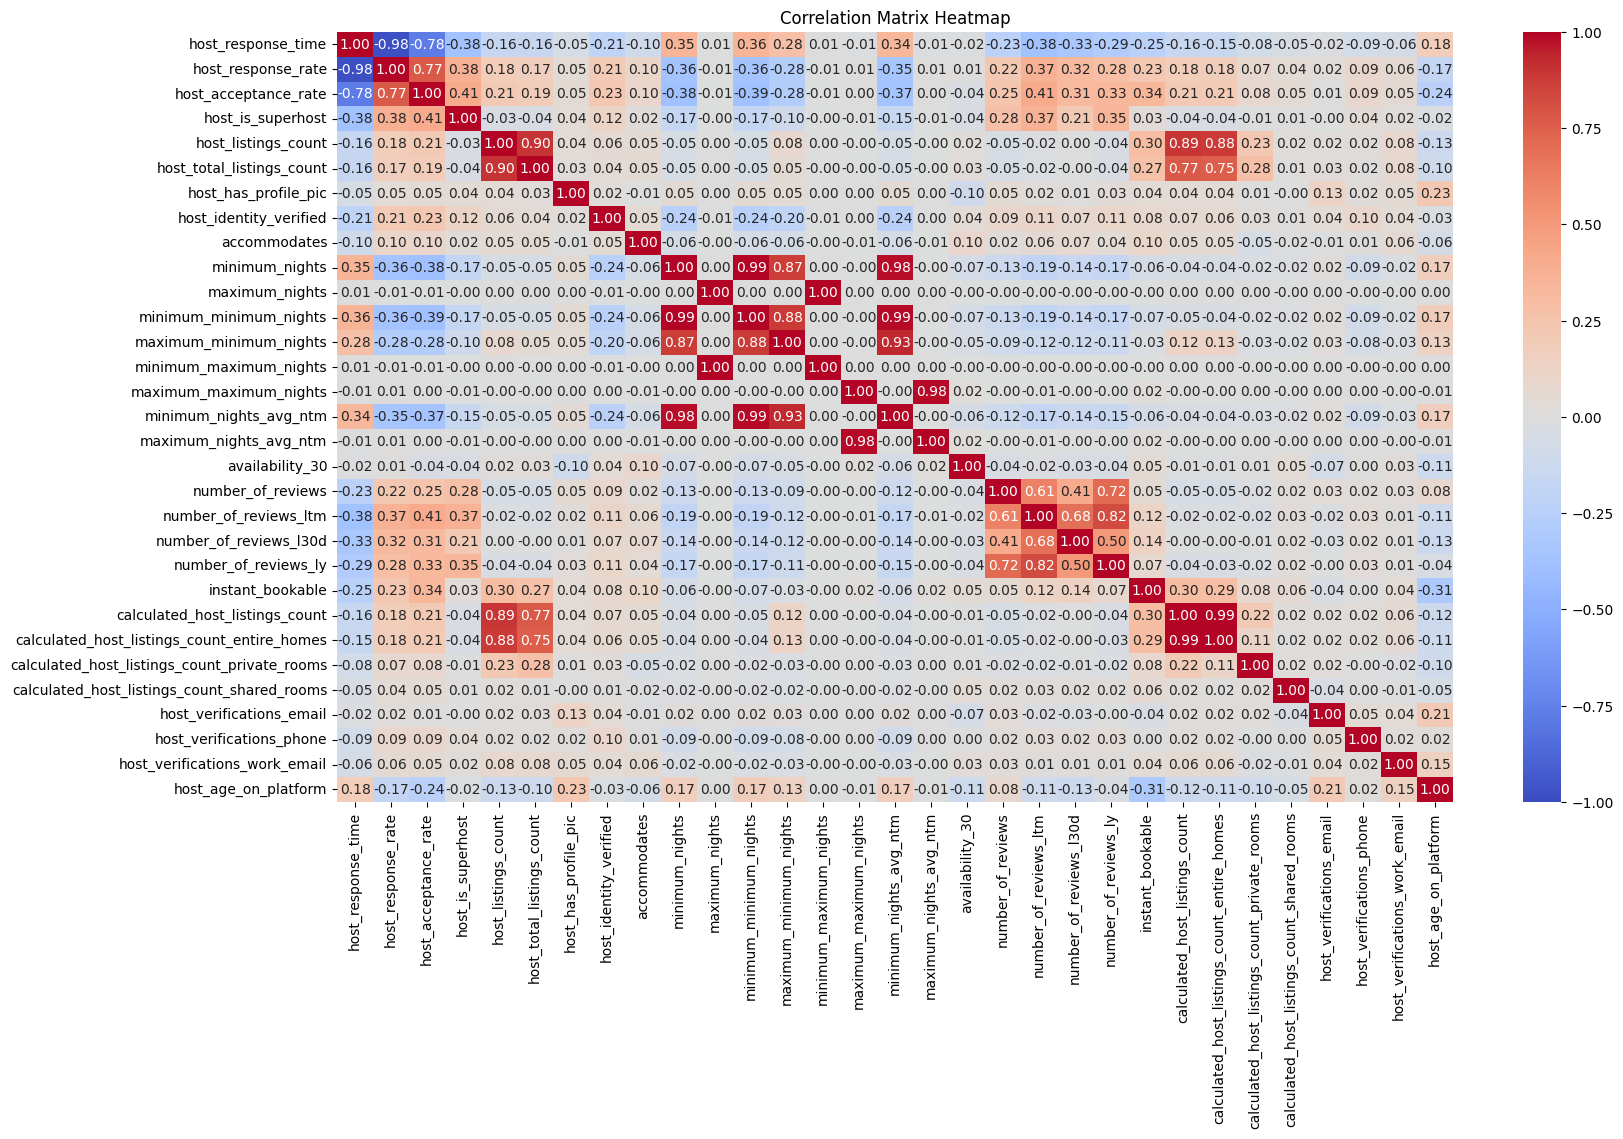

In [ ]:
import seaborn as sns

corr_matrix = df3.corr()


plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix Heatmap')

## Feature engineering

In [ ]:
df3 = df.copy()

df3['host_response_time'] = df3['host_response_time'].apply(int)

for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
    df3[col] = df3[col].apply(bool)

# drop_col_list = df3.select_dtypes(exclude=['int', 'bool', 'float']).columns

# df3 = df3.drop(columns=list(drop_col_list) + ['latitude', 'longitude'])

# Для признаков, содержащих мало пропусков, просто выкидываю значения
few_null_values_col_list = [
    'host_listings_count',
    'host_total_listings_count',                         
    'minimum_minimum_nights',     
    'maximum_minimum_nights',       
    'minimum_maximum_nights',
    'maximum_maximum_nights',
]
for col in few_null_values_col_list:
    df3 = df3[~df3[col].isna()]

# Признаки, содержащие много пропусков пока просто удаляю
many_null_values_col_list = [
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'bedrooms',
]

df3 = df3.drop(columns=many_null_values_col_list)

print('Кол-во пропусков = ', df3.isnull().sum().sum())
print(df3.shape)

Кол-во пропусков =  213758
(81820, 48)


In [26]:
import numpy as np

Для нахождения расстояния между двумя координатми воспользуемся формулой Гаверсина:
$$a = \sin^2\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1) \cdot \cos(\phi_2) \cdot \sin^2\left(\frac{\Delta \lambda}{2}\right)$$
$$c = 2 \cdot \operatorname{atan2}\left(\sqrt{a}, \sqrt{1-a}\right)$$
$$d = R \cdot c$$

где:
* φ₁, φ₂: Latitudes of point 1 and point 2 (in radians).
* λ₁, λ₂: Longitudes of point 1 and point 2 (in radians).
* R: Radius of the Earth (mean radius ≈ 6,371 km or 3,959 miles).
* Δ φ: φ₂ - φ₁ (difference in latitudes).
* Δ λ: λ₂ - λ₁ (difference in longitudes)


In [27]:
def haversine_distance(lat1, lon1, lat2, lon2):

    # Радиус Земли в км.
    R = 6371.0  

    # Преобразуем в радианы и находим разнцицу в широте и долготе между точками
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)

    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.atan2(np.sqrt(a), np.sqrt(1 - a))

    distance = R * c

    return distance

### Sighseengs distances

In [ ]:
sighseeng_coordinates = {
    'Eiffel Tower': (48.8584, 2.2945), 
    'ELouvre Museum': (48.8606, 2.3376), 
    'ENotre-Dame Cathedral': (48.8530, 2.3499), 
    'EArc de Triomphe': (48.8738, 2.2950), 
    "EMusée d'Orsay": (48.8600, 2.3266), 
    'ESacré-Cœur Basilica': (48.8867, 2.3431),
    'EChamps-Élysées': (48.8705, 2.3049),
}

for col in sighseeng_coordinates:
    df3['distance_' + col] = df3.apply(lambda x: haversine_distance(
        lat1=x.latitude,
        lon1=x.longitude, 
        lat2=sighseeng_coordinates[col][0],
        lon2=sighseeng_coordinates[col][1],
        ), axis=1
        )

# df3[['latitude', 'longitude']]

### Nearest metro distance

In [29]:
metro_df = pd.read_csv('prepared_data\metro_rer_idf.csv')

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\alrvt\AppData\Local\Temp\ipykernel_23264\3824154836.py:1: SyntaxWarning: invalid escape sequence '\m'
  metro_df = pd.read_csv('prepared_data\metro_rer_idf.csv')


In [30]:
metro_df.columns

Index(['ligne', 'station', 'ordre', 'correspondance', 'latitude', 'longitude'], dtype='str')

In [31]:
from scipy.spatial import KDTree


def find_nearest_metro_kdtree(df_airbnb, df_metro):
    # Convert degrees to radians for the tree
    metro_coords = np.radians(df_metro[["latitude", "longitude"]].values)
    airbnb_coords = np.radians(df_airbnb[["latitude", "longitude"]].values)

    # Build the tree with metro stations
    tree = KDTree(metro_coords)

    # Query the tree for the nearest neighbor
    distances_rad, indices = tree.query(airbnb_coords, k=1)

    # Convert radian distance back to kilometers (Multiply by Earth's radius)
    R = 6371.0

    df_airbnb["nearest_metro_name"] = df_metro.iloc[indices]["station"].values
    df_airbnb["nearest_metro_line"] = df_metro.iloc[indices]["ligne"].values
    df_airbnb["distance_to_metro_km"] = distances_rad * R

    return df_airbnb


In [ ]:
df4 = find_nearest_metro_kdtree(df3, metro_df)

In [33]:
df4 = df4.select_dtypes(include=['int', 'bool', 'float'])

In [34]:

X = df4.drop(columns=['availability_30'])
y = df4['availability_30']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

100%|██████████| 19/19 [00:26<00:00,  1.37s/it]


<Axes: xlabel='min_samples_leaf'>

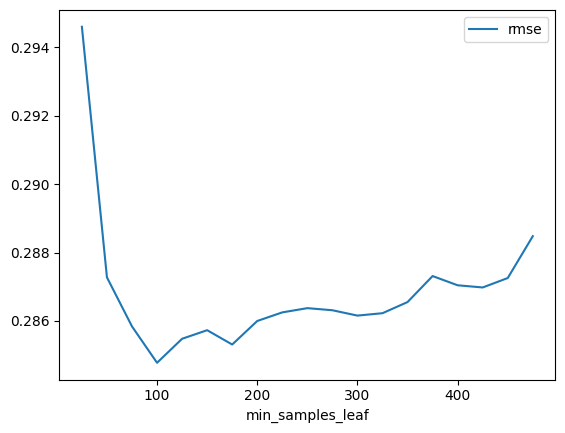

In [37]:
res = {
    'min_samples_leaf': [],
    'rmse': [],
}

for min_samples_leaf in tqdm(range(25, 500, 25)):

    tree_reg = DecisionTreeRegressor(min_samples_leaf=min_samples_leaf)

    tree_reg.fit(X_train2, y_train2)

    y_test_pred = tree_reg.predict(X_test2)
    y_train_pred = tree_reg.predict(X_train2)

    res['min_samples_leaf'] += [min_samples_leaf]
    res['rmse'] += [root_mean_squared_error(
        y_true=y_test2,
        y_pred=y_test_pred,
    )]

df_t3 = pd.DataFrame(res)

df_t3.plot(kind='line', x='min_samples_leaf', y='rmse')

In [42]:
from sklearn.ensemble import RandomForestRegressor

res = {
    'min_samples_leaf': [],
    'rmse_test': [],
    'rmse_train': [],
}

for min_samples_leaf in tqdm(range(50, 175, 25)):

    tree_reg = RandomForestRegressor(min_samples_leaf=min_samples_leaf)

    tree_reg.fit(X_train2, y_train2)

    y_test_pred = tree_reg.predict(X_test2)
    y_train_pred = tree_reg.predict(X_train2)

    res['min_samples_leaf'] += [min_samples_leaf]
    res['rmse_test'] += [root_mean_squared_error(
        y_true=y_test2,
        y_pred=y_test_pred,
    )]
    res['rmse_train'] += [root_mean_squared_error(
        y_true=y_train2,
        y_pred=y_train_pred,
    )]

df_t3 = pd.DataFrame(res)

100%|██████████| 5/5 [07:54<00:00, 94.84s/it] 


In [ ]:
for min_samples_leaf in tqdm(range(10, 25, 5)):

    tree_reg = RandomForestRegressor(min_samples_leaf=min_samples_leaf, random_state=42)

    tree_reg.fit(X_train2, y_train2)

    y_test_pred = tree_reg.predict(X_test2)
    y_train_pred = tree_reg.predict(X_train2)

    res['min_samples_leaf'] += [min_samples_leaf]
    res['rmse_test'] += [root_mean_squared_error(
        y_true=y_test2,
        y_pred=y_test_pred,
    )]
    res['rmse_train'] += [root_mean_squared_error(
        y_true=y_train2,
        y_pred=y_train_pred,
    )]

df_t3 = pd.DataFrame(res).sort_values(by='min_samples_leaf')

100%|██████████| 3/3 [06:52<00:00, 137.55s/it]


Text(0.5, 1.0, 'RandomForestRegressor')

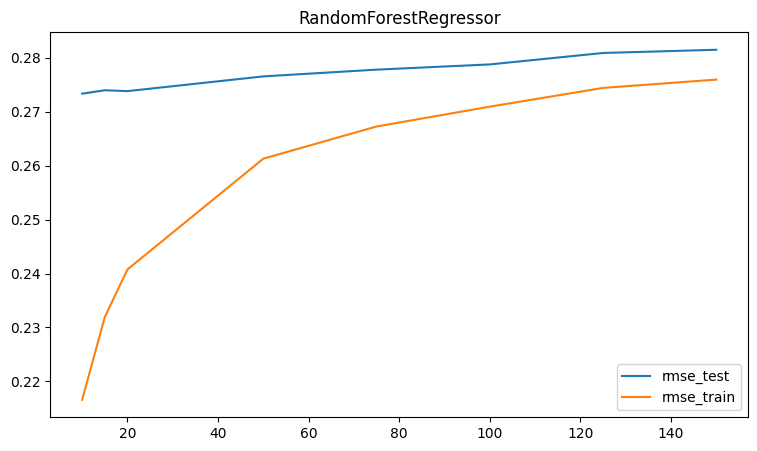

In [48]:
plt.figure(figsize=(9, 5))

plt.plot(df_t3['min_samples_leaf'], df_t3['rmse_test'], label='rmse_test')

plt.plot(df_t3['min_samples_leaf'], df_t3['rmse_train'], label='rmse_train')

plt.legend()
plt.title('RandomForestRegressor')

In [38]:
tree_reg = RandomForestRegressor(min_samples_leaf=100)

tree_reg.fit(X_train2, y_train2)

y_test_pred = tree_reg.predict(X_test2)
y_train_pred = tree_reg.predict(X_train2)

root_mean_squared_error(
    y_true=y_test2,
    y_pred=y_test_pred,
)



0.2790291720618175

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

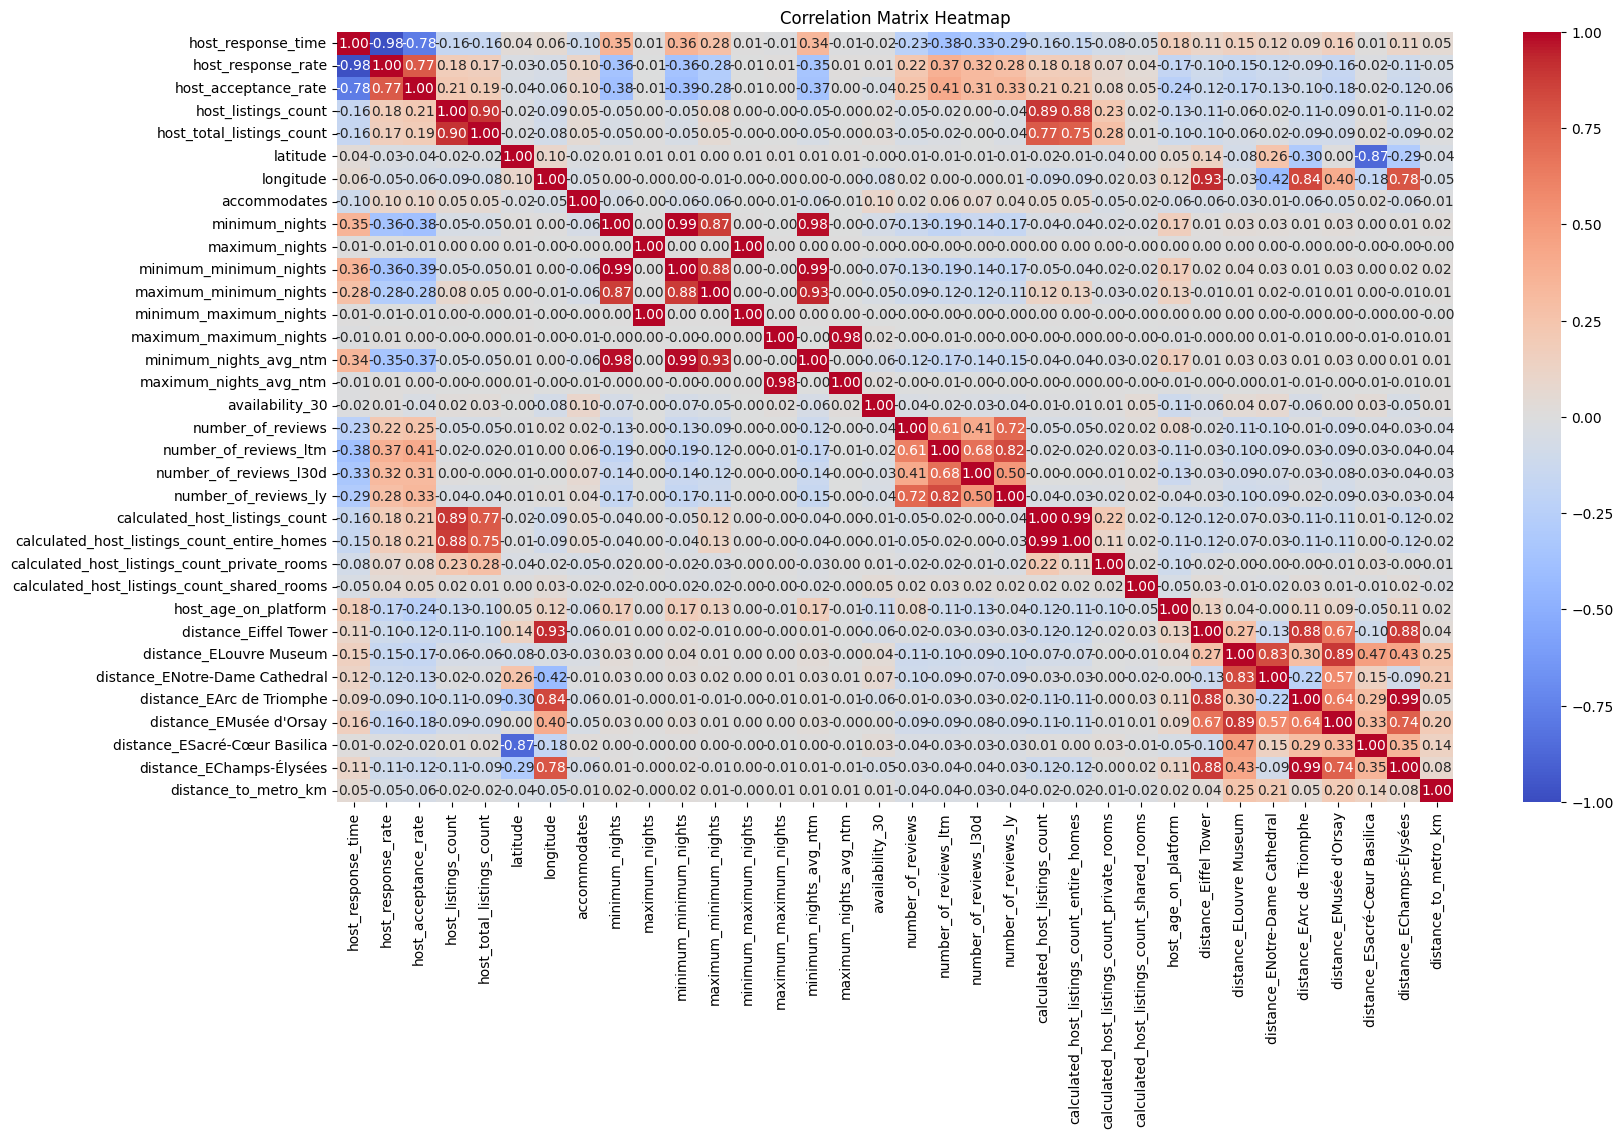

In [ ]:
import seaborn as sns

corr_matrix = df3.select_dtypes(['int', 'float']).corr()


plt.figure(figsize=(18, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Correlation Matrix Heatmap')